# Misurazione della rilevanza topologica

### Obiettivo
Misurare l'importanza della struttura topologica del grafo nella classificazione.

### Problema
Nei test precedenti, i modelli GNN avevano prestazioni sovrastate da quelle del MLP.
La motivazione è data dall'uso del modello: una GNN, tramite i layer di message passing, impara a propagare in modo significativo le informazioni attraverso gli archi del grafo. L'input dovrebbe quindi essere un altro grafo sul quale applicare gli operatori di message passing con gli stessi pesi appresi in fase di training.
Nel caso (degenere) in cui si passi un grafo composto da un solo nodo, la GNN regredisce ad un MLP come si può vedere dalla formula:
\begin{equation}
\mathbf{h}_v^{(k)} = \text{UPDATE}^{(k)}\left( \mathbf{h}_v^{(k-1)}, \text{AGGREGATE}^{(k)}\left( \left\{ \mathbf{h}_u^{(k-1)} \mid u \in \mathcal{N}(v) \right\} \right) \right)
\end{equation}
La funzione di aggregazione diventa nulla quando $\mathcal{N}(v) = \emptyset$ quindi:
\begin{equation}
\mathbf{h}_v^{(k)} = \text{UPDATE}^{(k)}( \mathbf{h}_v^{(k-1)}, 0)
\end{equation}

In molte architetture (GraphSAGE, GCN, ...) la funzione di UPDATE è un MLP

### Il test - Rewiring
Vista l'ambiguità, sarebbe utile misurare a priori se la topologia può aiutare nell'inferenza. Posso farlo con un test di rewiring: scambio casualmente gli archi da coppie di nodi, mantenendo il grado di ogni nodo ma effettivamente distruggendo la topologia.

NOTA BENE: questo test ha senso in un setting transductive in quanto nel setting inductive faccio inferenza su un nodo isolato, tornando al problema della sezione precedente.

COSA MI ASPETTO: Le prestazioni del modello addestrato sul grafo rewired devono crollare, nel caso migliore il modello "capisce" che la topologia non aiuta nella predizione e assegna dei pesi bassi alla propagazione dei messaggi, avvicinandosi ad un MLP. Le prestazioni del modello GNN addestrato su grafo normale dovrebbero essere molto più alte. 

### Definizione della pipeline e caricamento dataset

In [1]:
from data_pipeline import *
import torch_geometric.transforms as T


pre_transform = T.Compose([
    MarkCommonNodes(edge_types=('AD','PD')),
    DuplicateCommonNodesAndRelabel(suffix_ad='_AD', suffix_pd='_PD'),
    ReindexConsecutive(),
    MergeRelationsToHomogeneous(merge=['AD','PD'], edge_attr_reduce='sum'),
    FilterSmallConnectedComponents(topk=2)
])

ds = NeuroDegAnc2VecDataset(root='data', pre_transform=pre_transform)
data = ds[0]

/home/developer/Documents/Tesi/code_old/.venv/lib/python3.12/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /home/developer/Documents/Tesi/code_old/.venv/lib/python3.12/site-packages/libpyg.so: undefined symbol: _ZN3c1010Dispatcher17runRecordFunctionERN2at14RecordFunctionESt17reference_wrapperIKNS_14FunctionSchemaEENS_11DispatchKeyE
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/developer/Documents/Tesi/code_old/.venv/lib/python3.12/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/developer/Documents/Tesi/code_old/.venv/lib/python3.12/site-packages/torch_scatter/_version_cpu.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/developer/Documents/Tesi/code_old/.venv/lib/python3.12/site-packages/to

### Split dataset e definizione del training process
Esperimento in condizioni normali con setting inductive e transductive

In [2]:
from training_tools.splitter import StratifiedSplitterWithTestHoldout
from training_tools.task import TaskBinaryNodeClassification
from training_tools.trainer import Trainer
from training_tools.validation import CrossValidator
from training_tools.evaluation import Evaluator

from models import GCN, GCN_Sage, MLP
import pprint, tqdm

def compare_models_over_repeats(
    data,                   # Data
    model_factories,           # [factory_A, factory_B, ...]
    splitter_ctor,             # lambda seed, mode: StratifiedNestedSplitter(...)
    task, trainer, mode="transductive",
    n = 10
):
    seeds=list(range(n))
    # metriche per modello: dict[name] -> list of per-run test F1
    results = {i: [] for i in range(len(model_factories))}

    with tqdm.tqdm(total=len(seeds), desc="Training Progress", unit="iteration") as pbar:
        for seed in seeds:
            splitter = splitter_ctor(seed, mode)
            parts = splitter.split(data)

            for idx, factory in enumerate(model_factories):
                cv = CrossValidator(trainer=trainer, model_factory=factory, mode=mode, select_by="f1")
                artifacts, summary = cv.run(task, data, parts)

                evaluator = Evaluator(model_factory=factory, mode=mode)
                test_metrics = evaluator.evaluate(task, data, parts, artifacts["best_state"])
                results[idx].append(test_metrics["f1"])  # metrica primaria
            pbar.update(1)

    return results

model_factories = [
    lambda : GCN_Sage(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0),
    lambda : GCN(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0),
    lambda : MLP(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0)
]


splitter_ctor = lambda seed, mode: StratifiedSplitterWithTestHoldout(test_size=0.1, n_splits=5, seed=seed, mode=mode)

task    = TaskBinaryNodeClassification(threshold=0.5, pos_weight=None)
trainer = Trainer(lr=1e-3, weight_decay=5e-4, max_epochs=50, patience=10)

results = dict()

results['inductive']    = compare_models_over_repeats(data, model_factories, splitter_ctor, task, trainer, mode='inductive', n=50)
results['transductive'] = compare_models_over_repeats(data, model_factories, splitter_ctor, task, trainer, mode='transductive', n=50)


Training Progress: 100%|██████████| 50/50 [01:55<00:00,  2.31s/iteration]


### Plot
Qui mi aspetto di vedere che in modalità transductive GNN > MLP ma in modalità inductive GNN ~ MLP

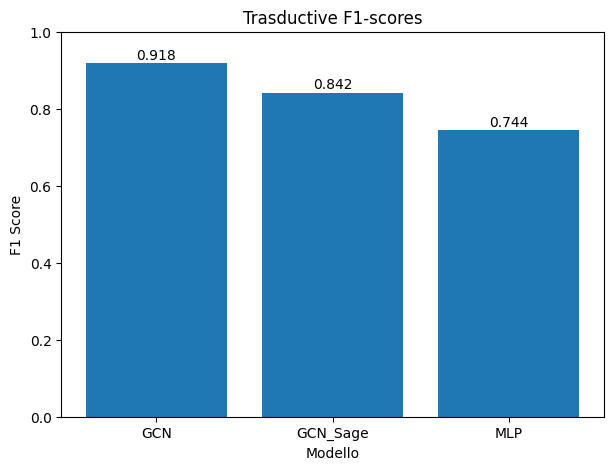

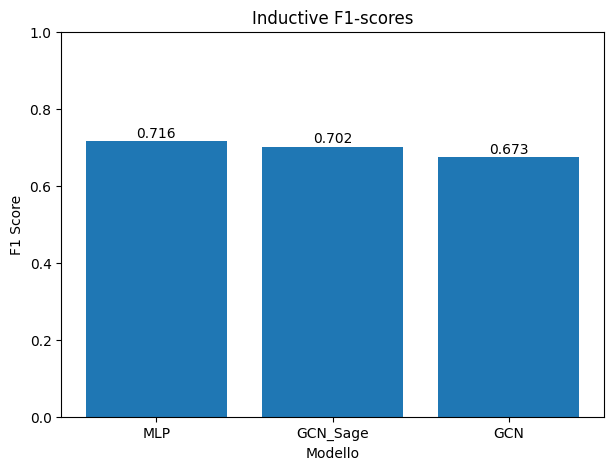

In [3]:
import numpy as np
import matplotlib.pyplot as plt

model_names = [model().__class__.__name__ for model in model_factories]

formatted_transductive  = dict(zip(model_names, [np.array(res).mean() for _, res in results['transductive'].items()]))
formatted_inductive     = dict(zip(model_names, [np.array(res).mean() for _, res in results['inductive'].items()]))


def plot_f1(formatted, title):
    sorted_formatted = dict(sorted(formatted.items(), key=lambda x: x[1], reverse=True))

    names = list(sorted_formatted.keys())
    values = list(sorted_formatted.values())

    plt.figure(figsize=(7, 5))
    plt.bar(names, values)
    plt.title(title)
    plt.ylabel("F1 Score")
    plt.xlabel("Modello")
    plt.ylim(0, 1)  # opzionale

    for i, v in enumerate(values):
        plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

    plt.show()

plot_f1(formatted_transductive  , title='Trasductive F1-scores')
plot_f1(formatted_inductive     , title='Inductive F1-scores')


### Codice Rewiring

In [4]:
# -*- coding: utf-8 -*-
from __future__ import annotations
import re
from typing import Optional, Dict, List, Tuple
import torch
from torch import Tensor
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected, remove_self_loops
import networkx as nx
import random


def _make_simple_undirected(edge_index: Tensor, num_nodes: int) -> Tensor:
    """Rende il grafo semplice e non orientato: rimuove self-loop, deduplica, simmetrizza."""
    ei, _ = remove_self_loops(edge_index)
    # tieni solo una direzione per deduplicare (i<j)
    i, j = ei
    mask_upper = i < j
    iu = torch.where(mask_upper, i, j)
    ju = torch.where(mask_upper, j, i)
    ei_u = torch.stack([iu, ju], dim=0)
    # rimuovi duplicati
    ei_u = torch.unique(ei_u, dim=1)
    # simmetrizza
    ei_ud = to_undirected(ei_u, num_nodes=num_nodes)
    return ei_ud


def _nx_from_edge_index(edge_index: Tensor, num_nodes: int) -> nx.Graph:
    """Crea un grafo semplice di NetworkX mantenendo gli indici 0..N-1 come label nodi."""
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))
    # usa solo metà superiore per evitare duplicati
    i, j = edge_index
    mask = i < j
    edges = torch.stack([i[mask], j[mask]], dim=0).T.tolist()
    G.add_edges_from(edges)
    return G


def _edge_index_from_nx(G: nx.Graph, num_nodes: int, device: torch.device) -> Tensor:
    """Converte nx.Graph -> edge_index non orientato, semplice."""
    if G.number_of_edges() == 0:
        return torch.empty((2, 0), dtype=torch.long, device=device)
    import numpy as np
    e = np.array(G.edges(), dtype=int)
    ei = torch.as_tensor(e.T, dtype=torch.long, device=device)
    ei = _make_simple_undirected(ei, num_nodes=num_nodes)
    return ei


def _double_edge_swap_safe(
    G: nx.Graph, nswap: int, max_tries: int, ensure_connected: bool, seed: int | random.Random
) -> nx.Graph:
    """Esegue il double-edge-swap con fallback progressivo se non converge."""
    rng = seed if isinstance(seed, random.Random) else random.Random(seed)
    H = G.copy()
    try:
        if ensure_connected:
            nx.connected_double_edge_swap(H, nswap=nswap, max_tries=max_tries, seed=rng)
        else:
            nx.double_edge_swap(H, nswap=nswap, max_tries=max_tries, seed=rng)
        return H
    except nx.NetworkXError:
        # fallback: riduci nswap a metà finché riesce
        cur = max(nswap // 2, 1)
        while cur >= 1:
            try:
                if ensure_connected:
                    nx.connected_double_edge_swap(H, nswap=cur, max_tries=max(max_tries, 10_000), seed=rng)
                else:
                    nx.double_edge_swap(H, nswap=cur, max_tries=max(max_tries, 10_000), seed=rng)
                return H
            except nx.NetworkXError:
                cur //= 2
        return G.copy()  # nessun rewiring possibile: ritorna l’originale


def rewire_degree_preserving(
    data: Data,
    *,
    seed: int = 0,
    swaps_per_edge: float = 10.0,
    max_tries_factor: float = 10.0,
    ensure_connected: bool = False,
    stratify_by_suffix: bool = True,
    suffix_regex: str = r"_(AD|PD)$",
) -> Data:
    """
    Rewiring degree-preserving per esperimenti transductive.

    Parametri
    ---------
    data : Data
        Oggetto PyG con campi almeno: x, edge_index, y.
        (Opz.) string_id: List[str] con suffisso '_AD'/'_PD' per la stratificazione.
    seed : int
        Seed per la randomizzazione.
    swaps_per_edge : float
        Numero target di swap ~ swaps_per_edge * |E_half| (dove E_half è il numero di archi non duplicati).
    max_tries_factor : float
        Fattore moltiplicativo per max_tries del double-edge-swap.
    ensure_connected : bool
        Se True, usa connected_double_edge_swap (più restrittivo).
    stratify_by_suffix : bool
        Se True, fa il rewiring separatamente per i nodi con suffisso '_AD' e '_PD' in string_id.
        Gli archi cross AD↔PD vengono lasciati invariati (conservativi).
    suffix_regex : str
        Regex per riconoscere i suffissi di malattia nei nomi dei nodi.

    Ritorna
    -------
    Data
        Una *copia* di `data` con `edge_index` rewired (edge_attr ricreato a 1).

    Note
    ----
    - Il grafo risultante è semplice, non orientato, senza self-loop.
    - edge_attr viene riassegnato a 1 (Tensor [E,1]) per neutralità.
    """
    g = data.clone()
    device = g.x.device if isinstance(g.x, torch.Tensor) else torch.device("cpu")
    N = g.num_nodes
    # normalizza edge_index a grafo semplice non orientato
    ei = _make_simple_undirected(g.edge_index.to('cpu'), num_nodes=N)

    # partizione per suffisso (se attiva)
    if stratify_by_suffix and hasattr(g, "string_id"):
        names: List[str] = list(getattr(g, "string_id"))
        suf_re = re.compile(suffix_regex)
        is_AD = torch.tensor([bool(suf_re.search(n) and n.endswith("_AD")) for n in names], dtype=torch.bool)
        is_PD = torch.tensor([bool(suf_re.search(n) and n.endswith("_PD")) for n in names], dtype=torch.bool)
        # nodi che non matchano il suffisso vanno in "others"
        is_other = ~(is_AD | is_PD)
    else:
        is_AD = torch.zeros(N, dtype=torch.bool)
        is_PD = torch.zeros(N, dtype=torch.bool)
        is_other = torch.ones(N, dtype=torch.bool)

    # Costruisci nx global e separa insiemi
    G_all = _nx_from_edge_index(ei, num_nodes=N)

    # separa archi intra-AD, intra-PD, intra-other e cross (AD↔PD / AD↔other / PD↔other)
    def _subset_edges(mask_u: Tensor, mask_v: Tensor) -> List[Tuple[int, int]]:
        uu = torch.nonzero(mask_u, as_tuple=False).view(-1)
        vv = torch.nonzero(mask_v, as_tuple=False).view(-1)
        u_set, v_set = set(uu.tolist()), set(vv.tolist())
        out = []
        for (u, v) in G_all.edges():
            a = (u in u_set) and (v in v_set)
            b = (v in u_set) and (u in v_set)
            if a or b:
                out.append((min(u, v), max(u, v)))
        return out

    # crea subgrafi per le tre “intra” e lascia i cross fermi (conservativo)
    parts: Dict[str, Dict] = {}
    for tag, m in {"AD": is_AD, "PD": is_PD, "OT": is_other}.items():
        nodes = torch.nonzero(m, as_tuple=False).view(-1).tolist()
        if len(nodes) == 0:
            continue
        H = G_all.subgraph(nodes).copy()
        parts[tag] = {"nodes": nodes, "G": H}

    # rewiring su ciascun subgrafo “intra”
    rng = random.Random(seed)
    for tag, d in parts.items():
        H = d["G"]
        E = H.number_of_edges()
        if E == 0:
            continue
        nswaps = max(1, int(swaps_per_edge * E))
        max_tries = max(10_000, int(max_tries_factor * nswaps))
        parts[tag]["G_rew"] = _double_edge_swap_safe(H, nswap=nswaps, max_tries=max_tries,
                                                     ensure_connected=ensure_connected, seed=rng)
    # ricompone il grafo: sostituisce solo le intra-edges, lascia invariati i cross
    G_new = nx.Graph()
    G_new.add_nodes_from(range(N))

    # aggiungi intra-edges rewired
    for tag, d in parts.items():
        if "G_rew" in d:
            G_new.add_edges_from(d["G_rew"].edges())

    # aggiungi i cross edges invariati
    # (cross = tutti gli edges originali non intra-AD, non intra-PD, non intra-OT)
    intra_all = set()
    for tag, d in parts.items():
        intra_all.update((min(u, v), max(u, v)) for (u, v) in d["G"].edges())
    cross_edges = []
    for (u, v) in G_all.edges():
        key = (min(u, v), max(u, v))
        if key not in intra_all:
            cross_edges.append((u, v))
    G_new.add_edges_from(cross_edges)

    # back to edge_index
    ei_new = _edge_index_from_nx(G_new, num_nodes=N, device=device)
    g.edge_index = ei_new

    # edge_attr neutro = 1 (shape [E,1])
    E_new = g.edge_index.size(1) // 2  # metà superiore *2 per simmetrizzazione
    g.edge_attr = torch.ones((2 * E_new, 1), dtype=torch.float32, device=device)

    return g


# ---------------------- Esempio d'uso ----------------------
# g_rewired = rewire_degree_preserving(
#     data,
#     seed=42,
#     swaps_per_edge=10.0,
#     ensure_connected=False,
#     stratify_by_suffix=True,     # usa suffissi _AD/_PD in string_id
#     suffix_regex=r"_(AD|PD)$",
# )
# # Ora puoi addestrare la GNN su g_rewired (transductive) e confrontare con il grafo reale.


### Test di Rewiring

Qui verranno fatti tre addestramenti in modalità transductive:
1. GCN (fatto come al solito)
2. GCN su grafo rewired
3. MLP

L'esperimento mostra:
1. Un crollo delle prestazioni sul modello (2);
2. Prestazioni comparabili tra il modello (2) e (3);

Interpretazione: Questo potrebbe indicare che i layer convoluzionali assegnano pesi molto bassi al MP, in quanto la topologia è stata fortemente alterata. Questo indica anche che la topologia non alterata aveva un significato biologico, e che la sua alterazione fa perdere informazione globale.

NOTE sul test: il rewiring è "degree preserving", lasciando invariati eventuali hotspot.


Training GCN on original and rewired graphs: 100%|██████████| 50/50 [01:31<00:00,  1.83s/trainings]


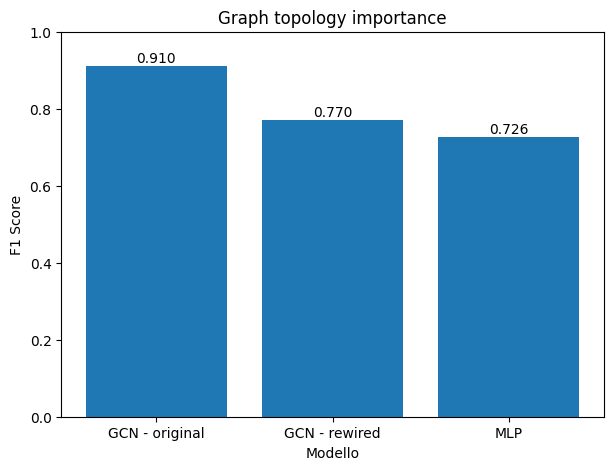

In [5]:
g_rewired = rewire_degree_preserving(
    data,
    seed=42,
    swaps_per_edge=10.0,
    ensure_connected=False,
    stratify_by_suffix=True,     # usa suffissi _AD/_PD in string_id
    suffix_regex=r"_(AD|PD)$",
)

mode = 'transductive'
seed = 42
factory = lambda : GCN(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0)

task    = TaskBinaryNodeClassification(threshold=0.5, pos_weight=None)
trainer = Trainer(lr=1e-3, weight_decay=5e-4, max_epochs=50, patience=10)

n = 50

test_metrics_mlp = compare_models_over_repeats(
    data, 
    [lambda : MLP(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0)], 
    splitter_ctor, task, trainer, mode='transductive', n=n)

test_metrics = [] 
test_metrics_rew = []

for x in tqdm.tqdm(range(n), desc="Training GCN on original and rewired graphs", unit="trainings"):
    splitter = StratifiedSplitterWithTestHoldout(test_size=0.1, n_splits=5, seed=x, mode=mode)
    parts = splitter.split(data)
    rewired_parts = splitter.split(g_rewired)

    cv = CrossValidator(trainer=trainer, model_factory=factory, mode=mode, select_by="f1")
    cv_rew = CrossValidator(trainer=trainer, model_factory=factory, mode=mode, select_by="f1")
    artifacts, summary = cv.run(task, data, parts)
    artifacts_rew, summary_rew = cv_rew.run(task, g_rewired, rewired_parts)

    evaluator = Evaluator(model_factory=factory, mode=mode)
    test_metrics.append(evaluator.evaluate(task, data, parts, artifacts["best_state"])['f1'])
    test_metrics_rew.append(evaluator.evaluate(task, g_rewired, rewired_parts, artifacts_rew["best_state"])['f1'])

formatted = {
    'GCN - original': np.array(test_metrics).mean(),
    'GCN - rewired' : np.array(test_metrics_rew).mean(),
    'MLP': np.array(list(test_metrics_mlp.values())).mean()
}
plot_f1(formatted, title='Graph topology importance')